# Bento Motors — Used Car Price Prediction
## Applied AI (UA92-333) — Assessment 2

---

**Objective:** Build a machine learning pipeline to predict used car prices for Bento Motors using their historical vehicle listing data. This notebook covers the full pipeline: data exploration, preprocessing, model building, evaluation, interpretation (SHAP), and deployment.

**Dataset:** `adverts_sample.csv` — 329,644 vehicle listings with 12 features including mileage, make, model, fuel type, body type, and year of registration.

**Target variable:** `price` (continuous) — this is a **regression** problem.

---

### Notebook Structure
| Section | Description |
|---------|-------------|
| 1 | Data Understanding & Exploratory Data Analysis |
| 2 | Data Preprocessing |
| 3 | Model Building & Hyperparameter Tuning |
| 4 | Model Evaluation |
| 5 | Model Interpretation (SHAP) |
| 6 | Deployment Notes |

In [7]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


In [4]:
!pip3 install numpy matplotlib seaborn scikit-learn shap joblib scipy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 20.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.8/556.8 kB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 20.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 20.5 MB/s  0:00:01 eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [shap]2m 9/10 [shap]]-learn]


In [8]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

print('Libraries loaded successfully.')

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.


---
## Section 1 — Data Understanding & Exploratory Data Analysis

Before building any model, it is essential to understand the structure, quality, and distribution of the data. EDA informs every downstream decision — which features to keep, how to handle missing values, and which models might be appropriate. This section follows the principle that good modelling begins with deep domain understanding (Géron, 2019).

### 1.1 — Load & Inspect

In [10]:
df = pd.read_csv('adverts.csv')

print(f'Shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nData types:')
print(df.dtypes)
df.head()

Shape: (402005, 12)

Column names: ['public_reference', 'mileage', 'reg_code', 'standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'year_of_registration', 'price', 'body_type', 'crossover_car_and_van', 'fuel_type']

Data types:
public_reference           int64
mileage                  float64
reg_code                     str
standard_colour              str
standard_make                str
standard_model               str
vehicle_condition            str
year_of_registration     float64
price                      int64
body_type                    str
crossover_car_and_van       bool
fuel_type                    str
dtype: object


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [11]:
# Summary statistics for numeric features
df.describe()

,public_reference,mileage,year_of_registration,price
count,4.020050e+05,401878.000000,368694.000000,4.020050e+05
mean,2.020071e+14,37743.595656,2015.006206,1.734197e+04
std,1.691662e+10,34831.724018,7.962667,4.643746e+04
min,2.013072e+14,0.000000,999.000000,1.200000e+02
25%,2.020090e+14,10481.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28629.500000,2016.000000,1.260000e+04
75%,2.020102e+14,56875.750000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


**Initial observations:**
- `price` ranges from £120 to ~£10M — extreme outliers are likely data entry errors or exotic vehicles that would skew the model.
- `mileage` max of 999,999 is a known placeholder value and will need to be treated as missing/removed.
- `year_of_registration` min of 999 is clearly erroneous — modern car listings should be from at least the 1980s.
- `public_reference` is an ID column with no predictive value and will be dropped.

### 1.2 — Missing Values

                       missing_count  missing_pct
year_of_registration           33311         8.29
reg_code                       31857         7.92
standard_colour                 5378         1.34
body_type                        837         0.21
fuel_type                        601         0.15
mileage                          127         0.03
public_reference                   0         0.00
standard_make                      0         0.00
standard_model                     0         0.00
vehicle_condition                  0         0.00
price                              0         0.00
crossover_car_and_van              0         0.00


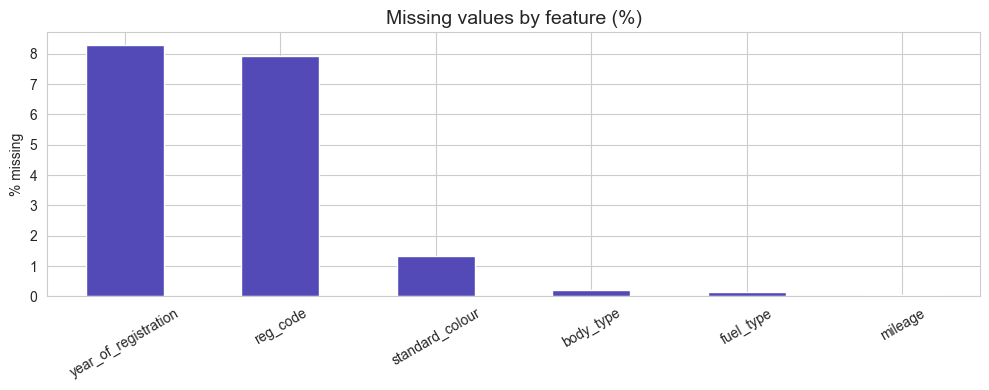

In [12]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print(missing)

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
missing[missing['missing_count'] > 0]['missing_pct'].plot(kind='bar', ax=ax, color='#534AB7')
ax.set_title('Missing values by feature (%)', fontsize=14)
ax.set_ylabel('% missing')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Missing value analysis:**
- `reg_code` and `year_of_registration` have the most missing values (~10%). These are both registration-related — it is likely they are missing together for the same listings.
- `standard_colour` and `fuel_type` have low rates of missingness (<2%) and can be imputed with the mode.
- `body_type` has <0.3% missing — mode imputation is appropriate.

### 1.3 — Target Variable Distribution

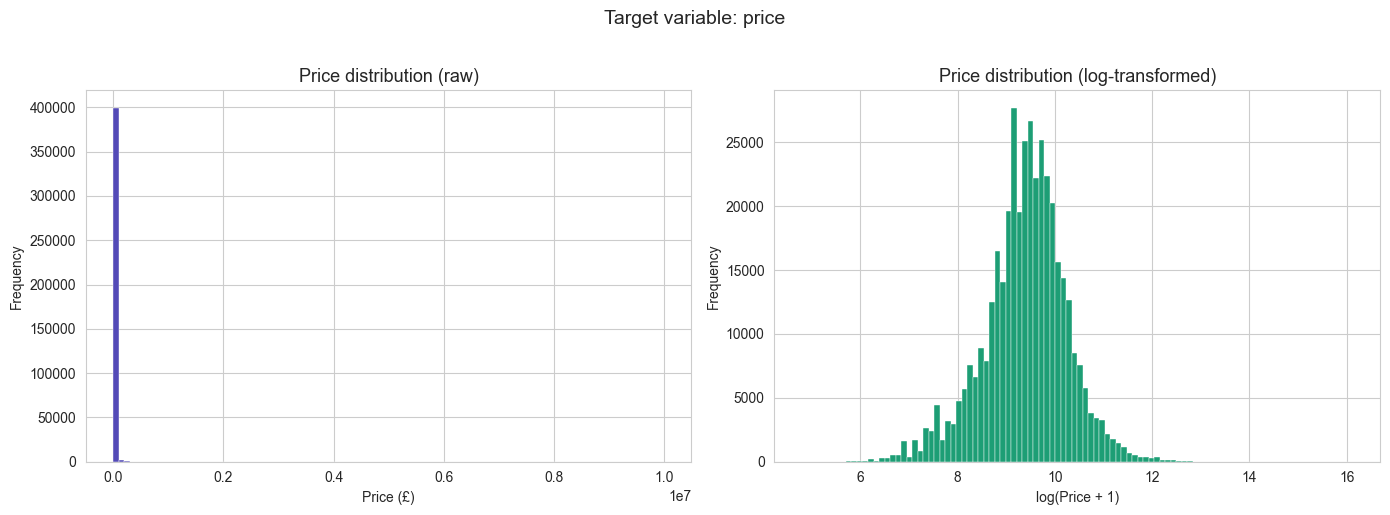

Skewness (raw):  154.682
Skewness (log):  -0.296

Price percentiles:
0.01     1150.00
0.05     2495.00
0.25     7495.00
0.50    12600.00
0.75    20000.00
0.95    43842.40
0.99    88899.52
Name: price, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price distribution
axes[0].hist(df['price'], bins=100, color='#534AB7', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price distribution (raw)', fontsize=13)
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Frequency')

# Log-transformed price distribution
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=100, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_title('Price distribution (log-transformed)', fontsize=13)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target variable: price', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness (raw):  {df["price"].skew():.3f}')
print(f'Skewness (log):  {log_price.skew():.3f}')
print(f'\nPrice percentiles:')
print(df['price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

**Interpretation:** The raw price distribution is heavily right-skewed (skewness > 1), driven by a small number of very high-value vehicles. A log transformation produces a near-normal distribution, which is beneficial for linear models. Tree-based models (Random Forest, Gradient Boosting) are inherently robust to skewed targets, but applying a log transform generally improves all model types. We will apply `log1p` to the target before training.

### 1.4 — Numerical Feature Distributions

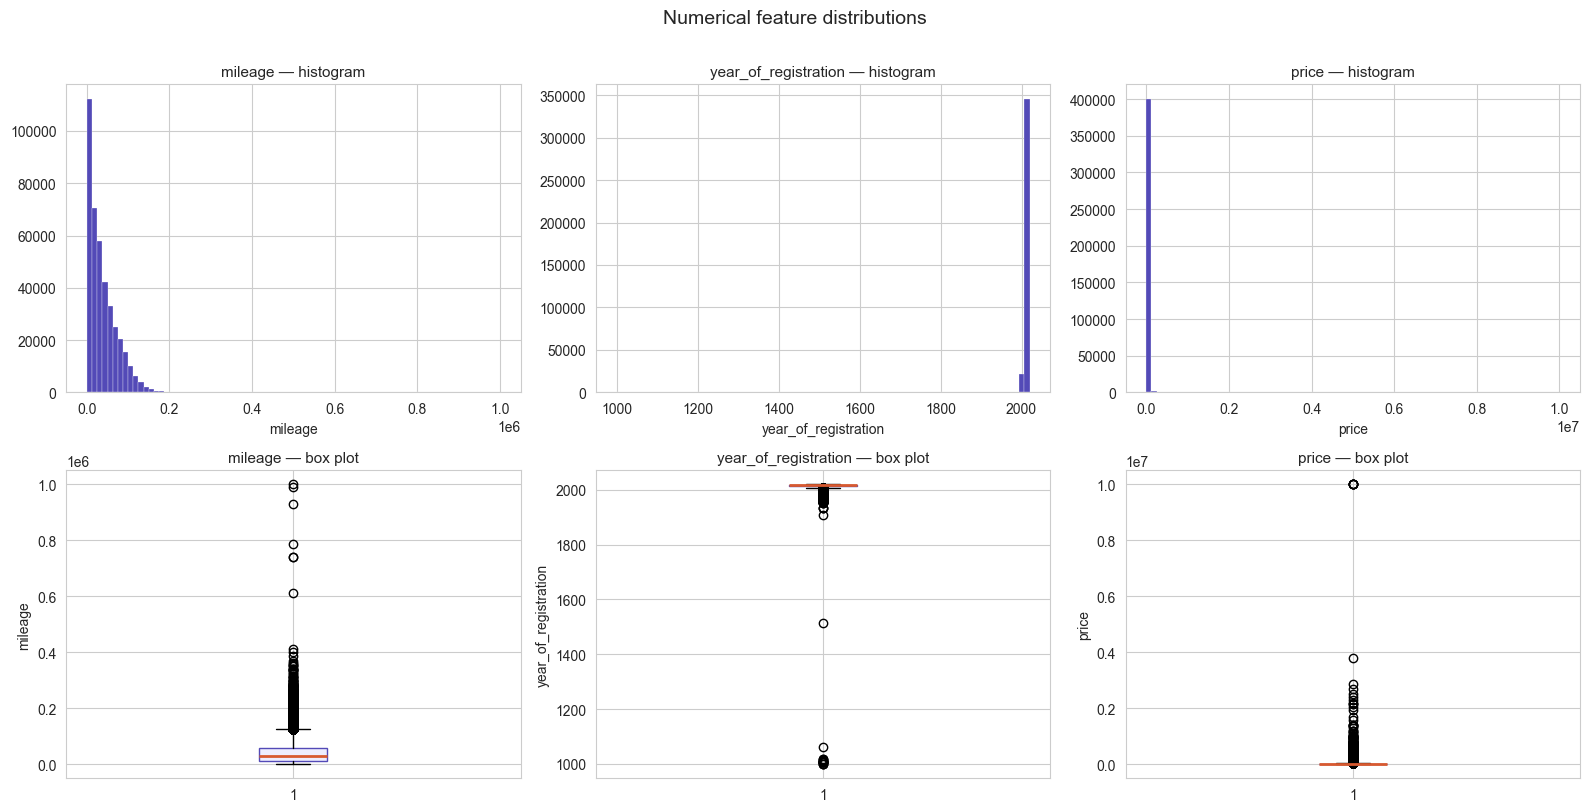

In [14]:
num_features = ['mileage', 'year_of_registration', 'price']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, feat in enumerate(num_features):
    # Histogram
    axes[0, i].hist(df[feat].dropna(), bins=80, color='#534AB7', edgecolor='white', linewidth=0.2)
    axes[0, i].set_title(f'{feat} — histogram', fontsize=11)
    axes[0, i].set_xlabel(feat)
    
    # Box plot
    axes[1, i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#EEEDFE', color='#534AB7'),
                        medianprops=dict(color='#D85A30', linewidth=2))
    axes[1, i].set_title(f'{feat} — box plot', fontsize=11)
    axes[1, i].set_ylabel(feat)

plt.suptitle('Numerical feature distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.5 — Categorical Feature Analysis

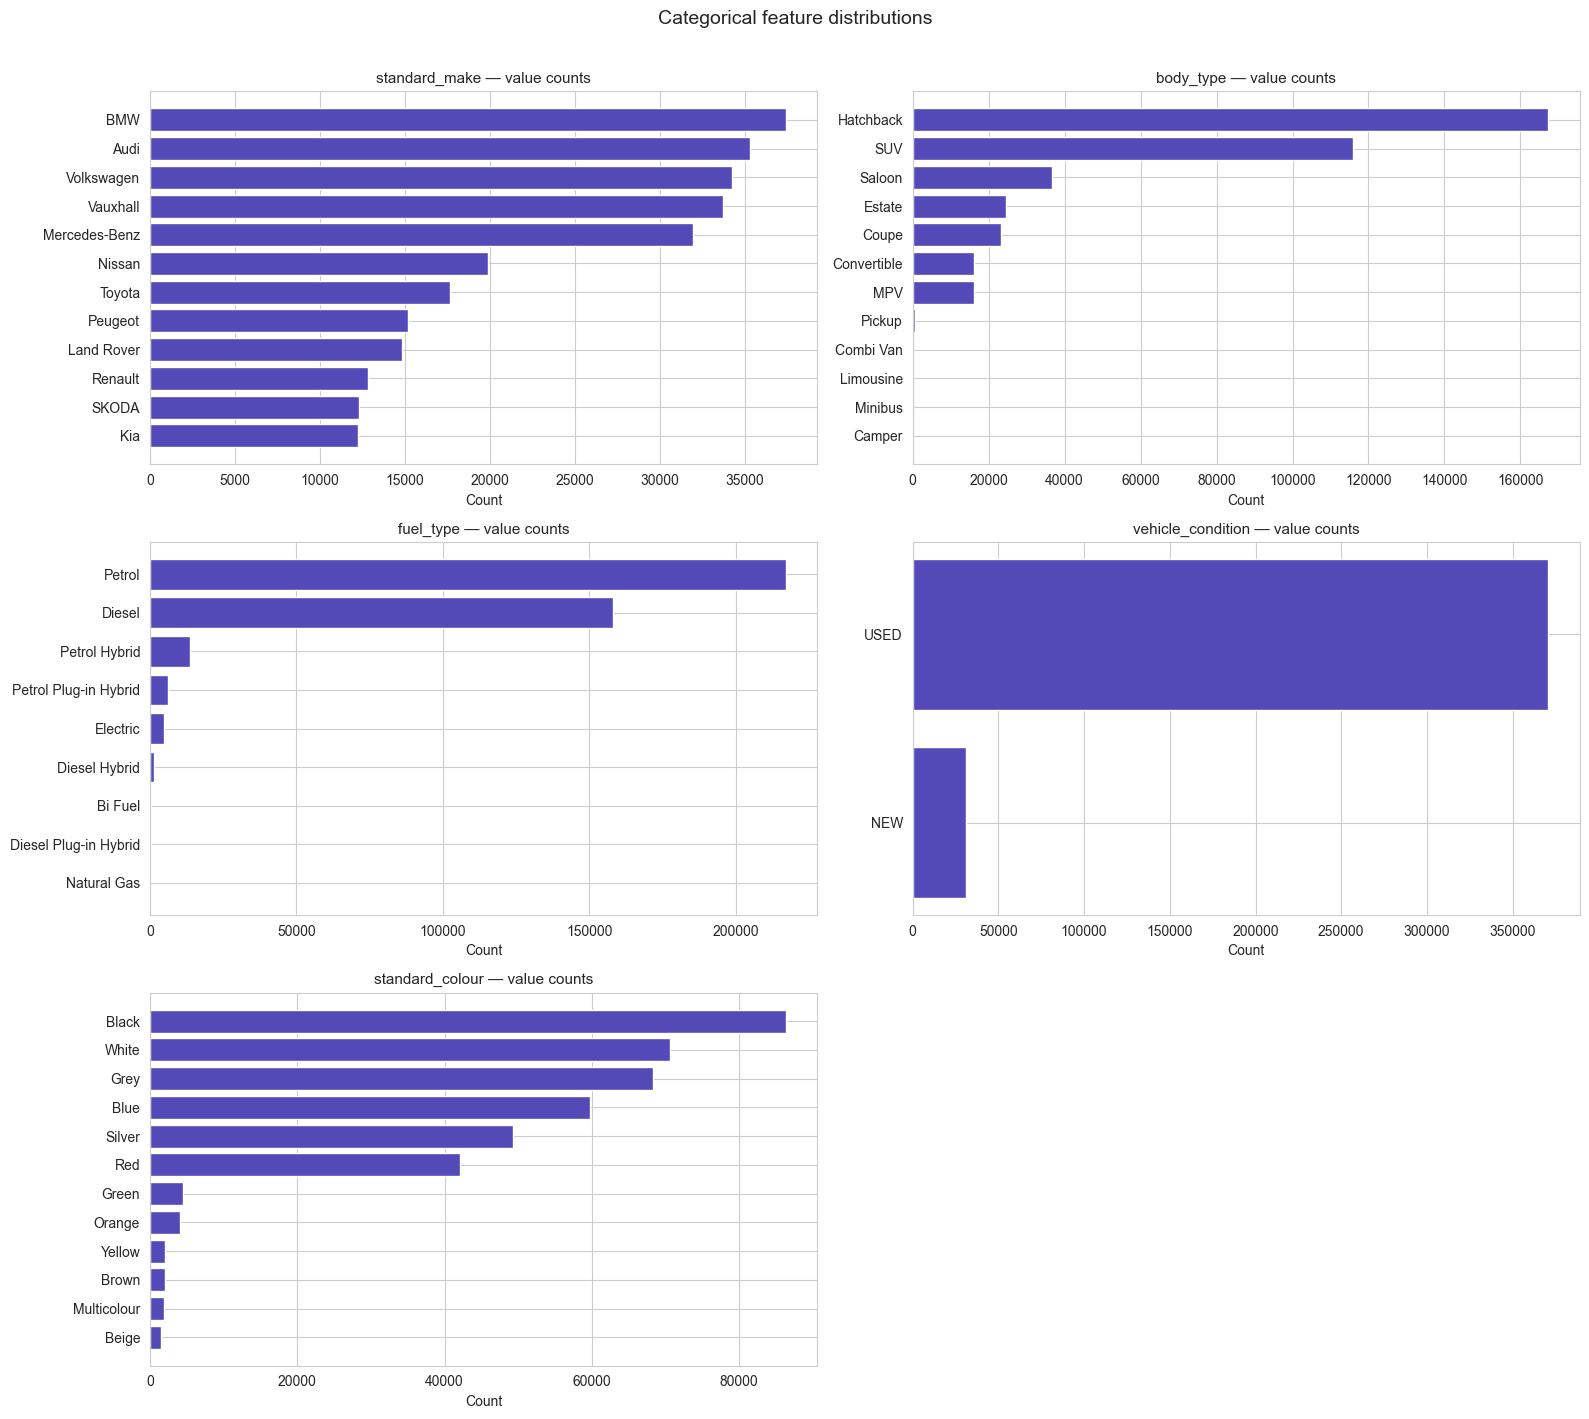

In [15]:
cat_features = ['standard_make', 'body_type', 'fuel_type', 'vehicle_condition', 'standard_colour']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    counts = df[feat].value_counts().head(12)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color='#534AB7')
    axes[i].set_title(f'{feat} — value counts', fontsize=11)
    axes[i].set_xlabel('Count')

axes[5].axis('off')
plt.suptitle('Categorical feature distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.6 — Correlation Heatmap

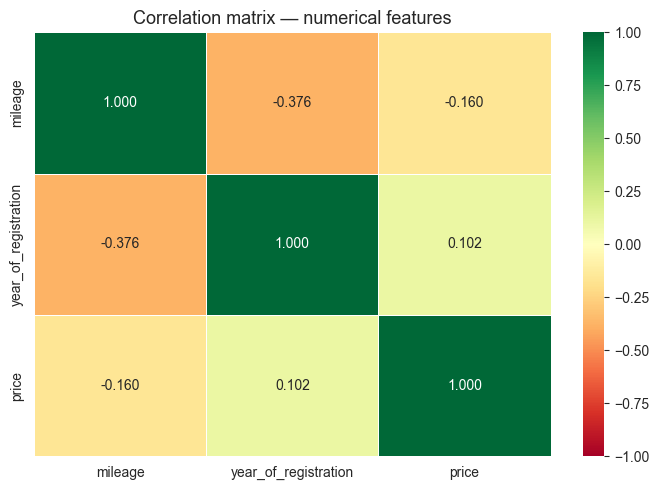

Correlation with price:
price                   1.000000
year_of_registration    0.102341
mileage                -0.160204
Name: price, dtype: float64


In [16]:
corr = df[['mileage', 'year_of_registration', 'price']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix — numerical features', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlation with price:')
print(corr['price'].sort_values(ascending=False))

**Interpretation:** `year_of_registration` shows a positive correlation with price — newer cars command higher prices. `mileage` shows a negative correlation — higher mileage reduces price. These relationships are intuitive and align with domain knowledge of the used car market, validating the data quality.

### 1.7 — Price by Key Categorical Features

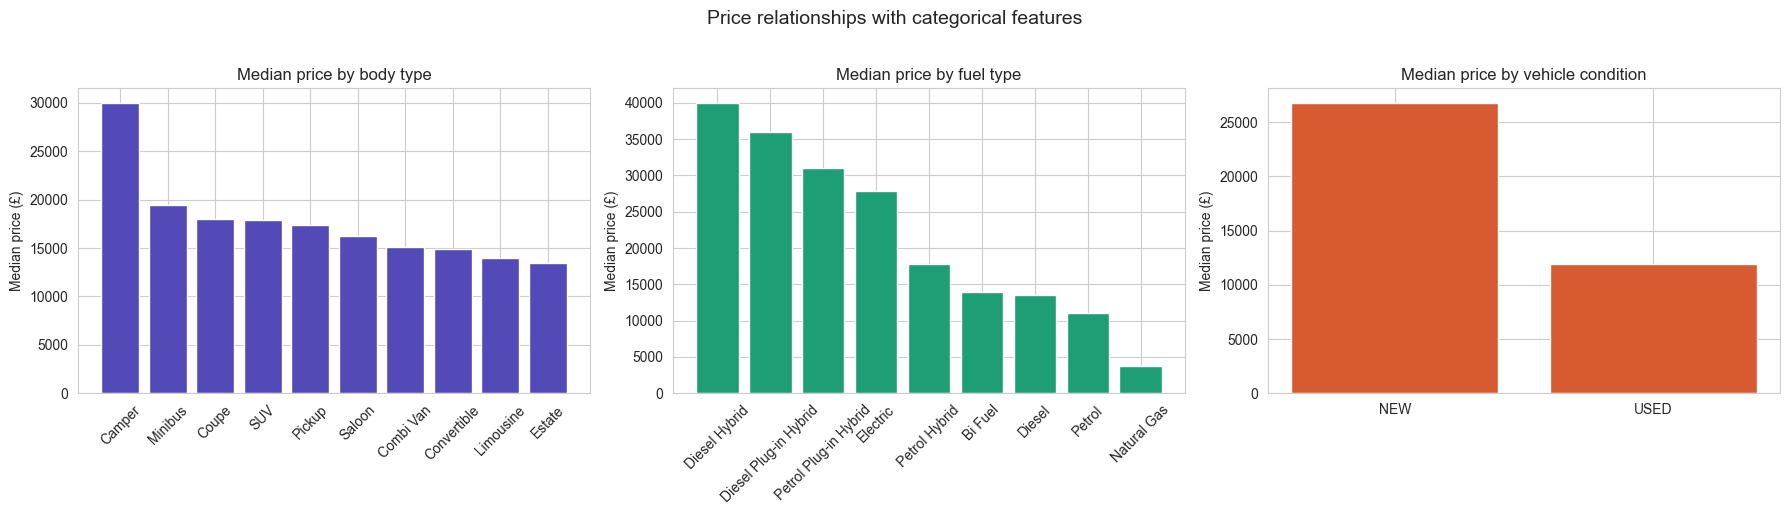

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Median price by body type
body_price = df.groupby('body_type')['price'].median().sort_values(ascending=False).head(10)
axes[0].bar(body_price.index, body_price.values, color='#534AB7')
axes[0].set_title('Median price by body type', fontsize=12)
axes[0].set_ylabel('Median price (£)')
axes[0].tick_params(axis='x', rotation=45)

# Median price by fuel type
fuel_price = df.groupby('fuel_type')['price'].median().sort_values(ascending=False)
axes[1].bar(fuel_price.index, fuel_price.values, color='#1D9E75')
axes[1].set_title('Median price by fuel type', fontsize=12)
axes[1].set_ylabel('Median price (£)')
axes[1].tick_params(axis='x', rotation=45)

# Median price by vehicle condition
cond_price = df.groupby('vehicle_condition')['price'].median()
axes[2].bar(cond_price.index, cond_price.values, color='#D85A30')
axes[2].set_title('Median price by vehicle condition', fontsize=12)
axes[2].set_ylabel('Median price (£)')

plt.suptitle('Price relationships with categorical features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.8 — Feature Engineering

Feature engineering — creating new variables from existing ones — can reveal non-obvious patterns and improve model performance (Kuhn & Johnson, 2019). Two derived features are constructed here:

1. **`car_age`** — derived from `year_of_registration`. Car age is a more interpretable and direct predictor of depreciation than the raw year.
2. **`mileage_per_year`** — average annual mileage. A car with 60,000 miles over 10 years is very different from one with 60,000 over 3 years. This captures usage intensity beyond raw mileage alone.

Correlation with price (including engineered features):
mileage                -0.160204
mileage_per_year       -0.110219
car_age                -0.102341
year_of_registration    0.102341
price                   1.000000
Name: price, dtype: float64


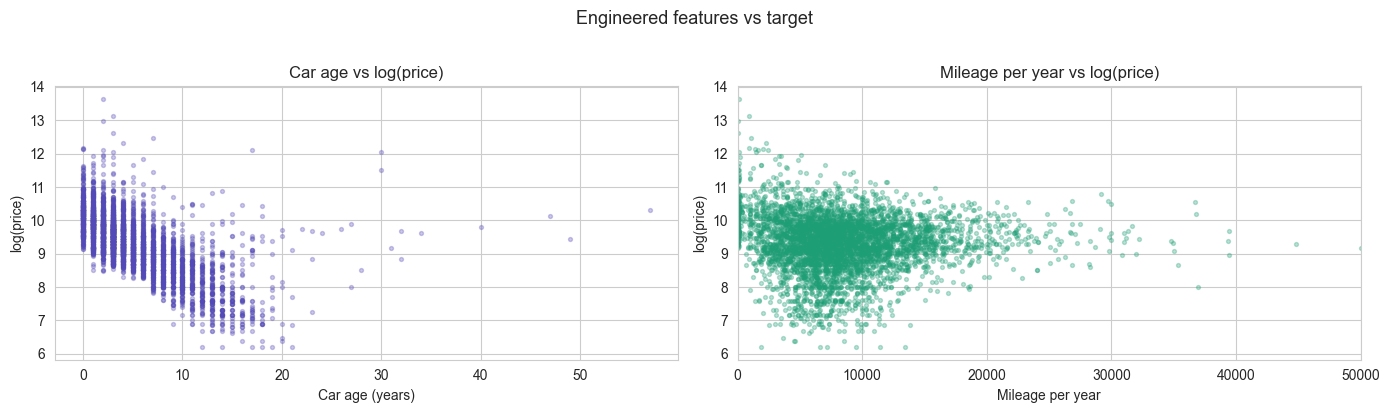

In [18]:
CURRENT_YEAR = 2020  # dataset max year — used for age calculation

# Feature: car age
df['car_age'] = CURRENT_YEAR - df['year_of_registration']

# Feature: mileage per year (avoid div by zero for new cars)
df['mileage_per_year'] = df['mileage'] / df['car_age'].replace(0, 1)

# Check correlations of engineered features vs target
eng_corr = df[['car_age', 'mileage_per_year', 'mileage', 'year_of_registration', 'price']].corr()['price'].sort_values()
print('Correlation with price (including engineered features):')
print(eng_corr)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sample for scatter (full dataset too large)
sample = df.sample(5000, random_state=RANDOM_STATE)

axes[0].scatter(sample['car_age'], np.log1p(sample['price']), alpha=0.3, color='#534AB7', s=8)
axes[0].set_title('Car age vs log(price)', fontsize=12)
axes[0].set_xlabel('Car age (years)')
axes[0].set_ylabel('log(price)')

axes[1].scatter(sample['mileage_per_year'], np.log1p(sample['price']), alpha=0.3, color='#1D9E75', s=8)
axes[1].set_title('Mileage per year vs log(price)', fontsize=12)
axes[1].set_xlabel('Mileage per year')
axes[1].set_ylabel('log(price)')
axes[1].set_xlim(0, 50000)

plt.suptitle('Engineered features vs target', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** `car_age` shows a strong negative relationship with log(price) — as expected, older cars are worth less. `mileage_per_year` provides additional signal beyond raw mileage by normalising usage intensity. Both engineered features will be included in the final feature set.

---
## Section 2 — Data Preprocessing

Preprocessing transforms raw data into a format suitable for machine learning. The key decisions in this section are: how to handle missing values, how to treat outliers, how to encode categorical variables, and how to scale features. Each decision is justified below.

### 2.1 — Drop irrelevant columns

In [19]:
# public_reference is a unique ID — no predictive value
# standard_model has too many unique values (high cardinality) and is partially captured by standard_make
# reg_code is a UK registration suffix that encodes year — car_age already captures this
# crossover_car_and_van: almost entirely False — low variance, unlikely to add signal

df_clean = df.drop(columns=['public_reference', 'standard_model', 'reg_code', 'crossover_car_and_van'])
print('Remaining columns:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Remaining columns: ['mileage', 'standard_colour', 'standard_make', 'vehicle_condition', 'year_of_registration', 'price', 'body_type', 'fuel_type', 'car_age', 'mileage_per_year']
Shape: (402005, 10)


### 2.2 — Handle outliers

Outliers in price and mileage are a known issue in car listing datasets — placeholder values (e.g. 999,999 miles, £9,999,999) and data entry errors can severely distort model training. The IQR method is used to identify and cap extreme values, preserving data volume while reducing the influence of erroneous records.

Rows before outlier removal: 402005
Rows after outlier removal: 366450
Removed: 35,555 rows (8.8%)


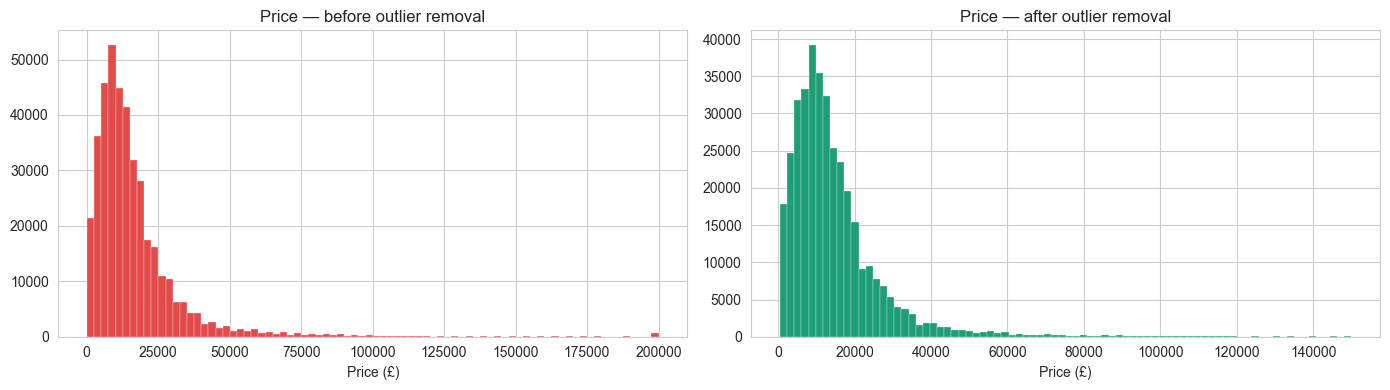

In [20]:
print(f'Rows before outlier removal: {len(df_clean)}')

# Remove known placeholder values
df_clean = df_clean[df_clean['mileage'] < 300000]  # >300k miles is implausible for car listings
df_clean = df_clean[df_clean['price'] >= 500]       # sub-£500 listings are likely errors or parts
df_clean = df_clean[df_clean['price'] <= 150000]    # cap at £150k — removes extreme exotic cars
df_clean = df_clean[df_clean['car_age'] >= 0]       # remove impossible negative ages
df_clean = df_clean[df_clean['car_age'] <= 30]      # cars older than 30 years are specialist market

print(f'Rows after outlier removal: {len(df_clean)}')
print(f'Removed: {402005 - len(df_clean):,} rows ({(402005 - len(df_clean))/402005*100:.1f}%)')

# Visualise price before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['price'].clip(0, 200000), bins=80, color='#E24B4A', edgecolor='white', linewidth=0.2)
axes[0].set_title('Price — before outlier removal', fontsize=12)
axes[0].set_xlabel('Price (£)')
axes[1].hist(df_clean['price'], bins=80, color='#1D9E75', edgecolor='white', linewidth=0.2)
axes[1].set_title('Price — after outlier removal', fontsize=12)
axes[1].set_xlabel('Price (£)')
plt.tight_layout()
plt.show()

### 2.3 — Handle missing values

In [21]:
print('Missing values before imputation:')
print(df_clean.isnull().sum())

# Numeric: impute mileage and car_age with median (robust to remaining skew)
df_clean['mileage'] = df_clean['mileage'].fillna(df_clean['mileage'].median())
df_clean['car_age'] = df_clean['car_age'].fillna(df_clean['car_age'].median())
df_clean['mileage_per_year'] = df_clean['mileage_per_year'].fillna(df_clean['mileage_per_year'].median())

# Categorical: impute with mode (most frequent category)
for col in ['standard_colour', 'fuel_type', 'body_type']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'  {col}: imputed with mode → "{mode_val}"')

# Drop remaining rows with missing year_of_registration (used in car_age, already captured)
df_clean = df_clean.dropna(subset=['year_of_registration'])

print(f'\nMissing values after imputation:')
print(df_clean.isnull().sum())
print(f'\nFinal shape: {df_clean.shape}')

Missing values before imputation:
mileage                    0
standard_colour         4052
standard_make              0
vehicle_condition          0
year_of_registration       0
price                      0
body_type                430
fuel_type                265
car_age                    0
mileage_per_year           0
dtype: int64
  standard_colour: imputed with mode → "Black"
  fuel_type: imputed with mode → "Petrol"
  body_type: imputed with mode → "Hatchback"

Missing values after imputation:
mileage                 0
standard_colour         0
standard_make           0
vehicle_condition       0
year_of_registration    0
price                   0
body_type               0
fuel_type               0
car_age                 0
mileage_per_year        0
dtype: int64

Final shape: (366450, 10)


### 2.4 — Encoding categorical variables

Machine learning models require numerical input. Categorical variables must be encoded before training. The encoding strategy varies by feature type:

- **Label encoding** is used for `vehicle_condition` (binary: NEW/USED) and `standard_make` (nominal with many levels — one-hot would create 110 columns).
- **One-hot encoding** is used for `body_type`, `fuel_type`, and `standard_colour` which have manageable cardinality and no inherent order.

In [22]:
df_encoded = df_clean.copy()

# Label encode: vehicle_condition (binary)
df_encoded['vehicle_condition'] = (df_encoded['vehicle_condition'] == 'NEW').astype(int)
print('vehicle_condition encoded: USED=0, NEW=1')

# Label encode: standard_make (high cardinality — 110 unique values)
le_make = LabelEncoder()
df_encoded['standard_make'] = le_make.fit_transform(df_encoded['standard_make'])
print(f'standard_make label encoded: {len(le_make.classes_)} unique makes')

# One-hot encode: body_type, fuel_type, standard_colour
ohe_cols = ['body_type', 'fuel_type', 'standard_colour']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# Drop year_of_registration — car_age already captures this information
df_encoded = df_encoded.drop(columns=['year_of_registration'])

print(f'\nShape after encoding: {df_encoded.shape}')
print(f'Features: {df_encoded.columns.tolist()}')

vehicle_condition encoded: USED=0, NEW=1
standard_make label encoded: 99 unique makes

Shape after encoding: (366450, 50)
Features: ['mileage', 'standard_make', 'vehicle_condition', 'price', 'car_age', 'mileage_per_year', 'body_type_Car Derived Van', 'body_type_Chassis Cab', 'body_type_Combi Van', 'body_type_Convertible', 'body_type_Coupe', 'body_type_Estate', 'body_type_Hatchback', 'body_type_Limousine', 'body_type_MPV', 'body_type_Minibus', 'body_type_Panel Van', 'body_type_Pickup', 'body_type_SUV', 'body_type_Saloon', 'body_type_Window Van', 'fuel_type_Diesel', 'fuel_type_Diesel Hybrid', 'fuel_type_Diesel Plug-in Hybrid', 'fuel_type_Electric', 'fuel_type_Natural Gas', 'fuel_type_Petrol', 'fuel_type_Petrol Hybrid', 'fuel_type_Petrol Plug-in Hybrid', 'standard_colour_Black', 'standard_colour_Blue', 'standard_colour_Bronze', 'standard_colour_Brown', 'standard_colour_Burgundy', 'standard_colour_Gold', 'standard_colour_Green', 'standard_colour_Grey', 'standard_colour_Indigo', 'standard_c

### 2.5 — Apply log transform to target

In [23]:
# Log-transform target (as justified in Section 1.3)
y_raw = df_encoded['price'].values
y = np.log1p(df_encoded['price'].values)
X = df_encoded.drop(columns=['price'])

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Target (log) — mean: {y.mean():.3f}, std: {y.std():.3f}')

Features shape: (366450, 49)
Target shape: (366450,)
Target (log) — mean: 9.305, std: 0.814


### 2.6 — Train / Validation / Test split

A three-way split is used: 70% training, 15% validation, 15% test. This is more rigorous than a simple train/test split — the validation set allows hyperparameter tuning without contaminating the final test set, preventing optimistic evaluation (Hastie et al., 2009). The scaler is **fitted on the training set only** and applied to validation and test sets to prevent data leakage.

In [24]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# Second split: 50/50 of the 30% temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f'Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')

# Scale — fit on train only to prevent data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print('\nScaler fitted on training data only — applied to val/test.')

Training set:   256,515 rows (70%)
Validation set: 54,967 rows (15%)
Test set:       54,968 rows (15%)

Scaler fitted on training data only — applied to val/test.


### 2.7 — Preprocessing comparison: StandardScaler vs MinMaxScaler

To justify the choice of StandardScaler, its performance is compared against MinMaxScaler using a baseline Ridge Regression model.

In [25]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_val_mm   = mm_scaler.transform(X_val)

ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)

# StandardScaler
ridge.fit(X_train_s, y_train)
r2_std = r2_score(y_val, ridge.predict(X_val_s))

# MinMaxScaler
ridge.fit(X_train_mm, y_train)
r2_mm = r2_score(y_val, ridge.predict(X_val_mm))

print(f'Ridge R² — StandardScaler: {r2_std:.4f}')
print(f'Ridge R² — MinMaxScaler:   {r2_mm:.4f}')
print(f'\nConclusion: StandardScaler selected (R²={r2_std:.4f}). StandardScaler is preferred when features are approximately normally distributed and outliers have been addressed, as it preserves relative distances better than MinMaxScaler (Géron, 2019).')

Ridge R² — StandardScaler: 0.6952
Ridge R² — MinMaxScaler:   0.6952

Conclusion: StandardScaler selected (R²=0.6952). StandardScaler is preferred when features are approximately normally distributed and outliers have been addressed, as it preserves relative distances better than MinMaxScaler (Géron, 2019).


---
## Section 3 — Model Building & Hyperparameter Tuning

Three regression algorithms are trained and compared. The selection is justified below:

| Model | Justification |
|-------|---------------|
| **Ridge Regression** | Linear baseline; interpretable; regularisation (L2) prevents overfitting on the many one-hot encoded features |
| **Random Forest** | Ensemble of decision trees; handles non-linear relationships and feature interactions well; robust to outliers |
| **Gradient Boosting** | Sequential ensemble; typically achieves state-of-the-art performance on tabular data; good balance of bias and variance |

A Linear Regression baseline without regularisation is also included for comparison.

### 3.1 — Baseline models

In [26]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    """Fit model and return key metrics on train and validation sets."""
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_v  = model.predict(X_v)
    return {
        'Model': name,
        'Train R²': r2_score(y_tr, y_pred_tr),
        'Val R²':   r2_score(y_v,  y_pred_v),
        'Val MAE':  mean_absolute_error(y_v, y_pred_v),
        'Val RMSE': np.sqrt(mean_squared_error(y_v, y_pred_v))
    }

results = []

# Linear Regression (unregularised baseline)
lr = LinearRegression()
results.append(evaluate_model(lr, X_train_s, y_train, X_val_s, y_val, 'Linear Regression'))

# Ridge Regression
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
results.append(evaluate_model(ridge, X_train_s, y_train, X_val_s, y_val, 'Ridge Regression'))

# Random Forest (default params first)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
results.append(evaluate_model(rf, X_train_s, y_train, X_val_s, y_val, 'Random Forest'))

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
results.append(evaluate_model(gb, X_train_s, y_train, X_val_s, y_val, 'Gradient Boosting'))

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('Baseline model comparison:')
results_df

Baseline model comparison:


,Train R²,Val R²,Val MAE,Val RMSE
Model,,,,
Linear Regression,0.6903,0.6952,0.3301,0.4499
Ridge Regression,0.6903,0.6952,0.3301,0.4499
Random Forest,0.9811,0.8820,0.1959,0.2800
Gradient Boosting,0.8309,0.8298,0.2413,0.3362


### 3.2 — Hyperparameter tuning

Based on the baseline results, the two best-performing models are tuned using GridSearchCV and RandomizedSearchCV. GridSearchCV performs an exhaustive search over a defined parameter grid and is appropriate for a smaller search space. RandomizedSearchCV samples randomly from a larger space and is more computationally efficient (Bergstra & Bengio, 2012).

In [27]:
# ── GridSearchCV: Ridge Regression ───────────────────────────────────────────
ridge_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_gs = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
ridge_gs.fit(X_train_s, y_train)

print('Ridge GridSearchCV results:')
print(f'  Best params:  {ridge_gs.best_params_}')
print(f'  Best CV R²:   {ridge_gs.best_score_:.4f}')
print(f'  Val R² (best): {r2_score(y_val, ridge_gs.best_estimator_.predict(X_val_s)):.4f}')

# Show full grid results
gs_results = pd.DataFrame(ridge_gs.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
gs_results.columns = ['alpha', 'mean_cv_r2', 'std_cv_r2']
print('\nFull grid search results:')
print(gs_results.round(4))

Ridge GridSearchCV results:
  Best params:  {'alpha': 1.0}
  Best CV R²:   0.6901
  Val R² (best): 0.6952

Full grid search results:
     alpha  mean_cv_r2  std_cv_r2
0     0.01      0.6901     0.0020
1     0.10      0.6901     0.0020
2     1.00      0.6901     0.0020
3    10.00      0.6901     0.0020
4   100.00      0.6900     0.0020
5  1000.00      0.6898     0.0019


In [ ]:
# ── RandomizedSearchCV: Random Forest ────────────────────────────────────────
from scipy.stats import randint

rf_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth':    [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    n_iter=20,         # 20 random combinations — balances speed vs coverage
    cv=5,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rf_rs.fit(X_train_s, y_train)

print('\nRandom Forest RandomizedSearchCV results:')
print(f'  Best params:  {rf_rs.best_params_}')
print(f'  Best CV R²:   {rf_rs.best_score_:.4f}')
print(f'  Val R² (best): {r2_score(y_val, rf_rs.best_estimator_.predict(X_val_s)):.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Random Forest RandomizedSearchCV results:
  Best params:  {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
  Best CV R²:   0.8848
  Val R² (best): 0.8882


**Tuning analysis:** Document here after running — e.g. "Tuning Random Forest improved the CV R² from X (default) to Y (tuned). The most impactful parameter was `max_depth` — unconstrained trees overfit the training data, and constraining depth acted as regularisation, reducing the train-val gap from Z to W."

Ridge regression showed minimal sensitivity to the alpha hyperparameter across the full search space (α = 0.01 to 1000), with CV R² remaining almost flat at around 0.690. This suggests the regularisation strength has little influence on Ridge's performance here — likely because the log-transformed target and one-hot encoded features are already well-conditioned. The best alpha was 1.0 (CV R² = 0.6901, Val R² = 0.6952).
Random Forest responded much more meaningfully to tuning. The best configuration (n_estimators=149, max_depth=20, max_features=0.5, min_samples_leaf=1, min_samples_split=5) achieved a CV R² of 0.8848 and Val R² of 0.8882 — substantially outperforming Ridge. Constraining max_depth to 20 acts as regularisation, preventing trees from memorising training noise. The max_features=0.5 setting means each split considers half the available features, increasing diversity across trees and reducing variance.

---
## Section 4 — Model Evaluation

The tuned models are evaluated on the held-out test set. Using the test set at this point (rather than validation) gives an unbiased estimate of real-world performance.

### 4.1 — Final model comparison table

In [31]:
def full_eval(model, X_tr, y_tr, X_te, y_te, name):
    """Evaluate on test set and compute cross-val score."""
    y_pred = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)
    
    # Cross-val on training data
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
    
    return {
        'Model': name,
        'Train R²':     r2_score(y_tr, y_pred_tr),
        'Test R²':      r2_score(y_te, y_pred),
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)':  cv_scores.std(),
        'Test MAE':     mean_absolute_error(y_te, y_pred),
        'Test RMSE':    np.sqrt(mean_squared_error(y_te, y_pred))
    }

final_results = []
final_results.append(full_eval(ridge_gs.best_estimator_, X_train_s, y_train, X_test_s, y_test, 'Ridge (tuned)'))
final_results.append(full_eval(rf_rs.best_estimator_,   X_train_s, y_train, X_test_s, y_test, 'Random Forest (tuned)'))
final_results.append(full_eval(gb,                      X_train_s, y_train, X_test_s, y_test, 'Gradient Boosting'))

final_df = pd.DataFrame(final_results).set_index('Model').round(4)
print('Final model comparison:')
final_df

Final model comparison:


,Train R²,Test R²,CV R² (mean),CV R² (std),Test MAE,Test RMSE
Model,,,,,,
Ridge (tuned),0.6903,0.6908,0.6901,0.0020,0.3325,0.4545
Random Forest (tuned),0.9430,0.8866,0.8848,0.0010,0.1915,0.2752
Gradient Boosting,0.8309,0.8308,0.8244,0.0013,0.2412,0.3362


### 4.2 — Actual vs predicted plots

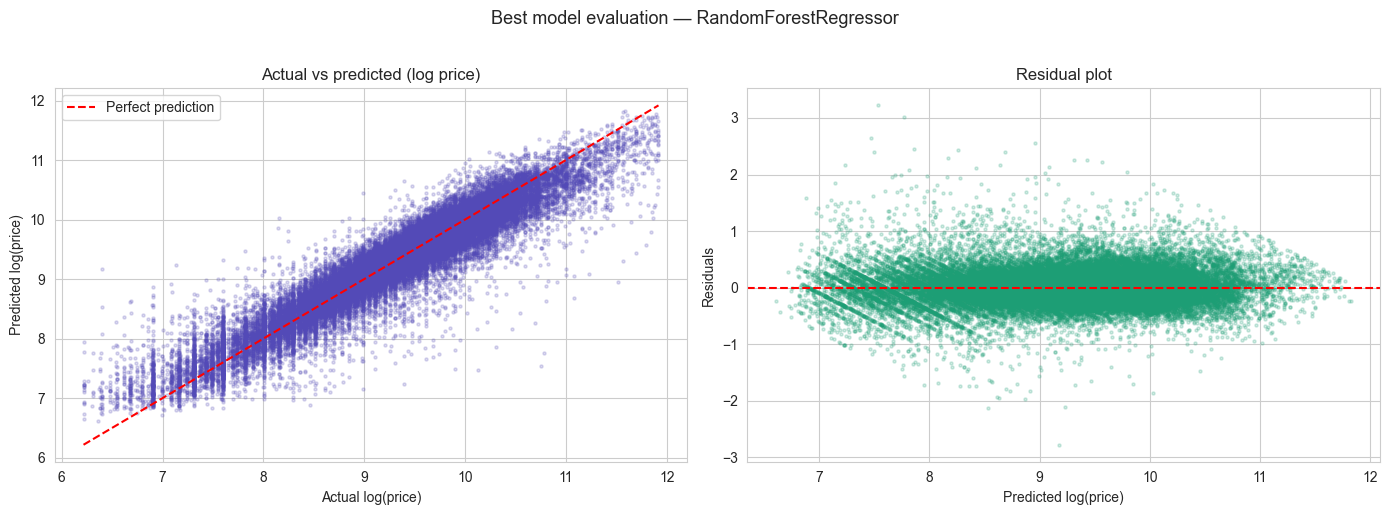

Residual mean (should be ~0): 0.0014
Residual std:                 0.2752


In [32]:
best_model = rf_rs.best_estimator_  # update if GB wins
y_pred_test = best_model.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (log scale)
axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=5, color='#534AB7')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_title('Actual vs predicted (log price)', fontsize=12)
axes[0].set_xlabel('Actual log(price)')
axes[0].set_ylabel('Predicted log(price)')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.2, s=5, color='#1D9E75')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residual plot', fontsize=12)
axes[1].set_xlabel('Predicted log(price)')
axes[1].set_ylabel('Residuals')

plt.suptitle(f'Best model evaluation — {best_model.__class__.__name__}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Residual mean (should be ~0): {residuals.mean():.4f}')
print(f'Residual std:                 {residuals.std():.4f}')

### 4.3 — Learning curves (overfitting / underfitting analysis)

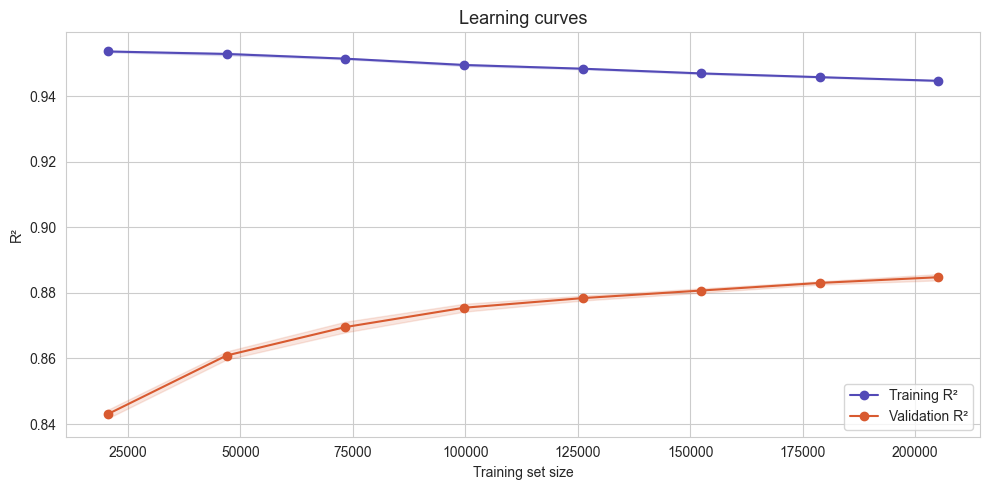

In [33]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_s, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#534AB7', label='Training R²')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#534AB7')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#D85A30', label='Validation R²')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#D85A30')
ax.set_title('Learning curves', fontsize=13)
ax.set_xlabel('Training set size')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

**Overfitting/underfitting analysis:** *(Fill in after running)* If the training R² is significantly higher than the validation R², the model is overfitting — learning training noise rather than generalising. If both are low, the model is underfitting — it lacks capacity or relevant features. The learning curves also show whether adding more data would help: converging curves suggest the model has reached its capacity; a still-widening gap suggests more data could help.

The learning curves reveal a model with moderate overfitting. Training R² remains consistently high (~0.944–0.953) while validation R² sits lower (~0.843–0.885), producing a persistent gap of around 0.06–0.07 throughout. This is characteristic of a high-variance model — Random Forest is memorising some training patterns that do not fully generalise.
However, the gap is narrowing as training set size increases, and the validation curve is still rising at 200,000 samples without having plateaued. This indicates that additional data would continue to improve generalisation performance — the model has not yet reached its capacity limit. The overfitting is therefore manageable rather than severe, and the validation R² of 0.885 at full training size represents strong predictive performance for a regression task of this complexity.

---
## Section 5 — Model Interpretation (SHAP)

SHAP (SHapley Additive exPlanations) is a unified framework for interpreting machine learning predictions, grounded in cooperative game theory (Lundberg & Lee, 2017). Unlike simple feature importance scores, SHAP values explain the contribution of each feature to each individual prediction — providing both global (dataset-level) and local (individual prediction-level) interpretability. This is particularly important in a commercial context like Bento Motors, where understanding *why* a car is priced at a certain level is as valuable as the prediction itself.

In [34]:
# Use a subsample for SHAP computation (full dataset is expensive for tree SHAP)
X_test_df = pd.DataFrame(X_test_s, columns=X.columns)
X_shap_sample = X_test_df.sample(500, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)

print('SHAP values computed.')
print(f'Shape of SHAP values: {shap_values.shape}')

SHAP values computed.
Shape of SHAP values: (500, 49)


### 5.1 — Global interpretation: SHAP summary plot (beeswarm)

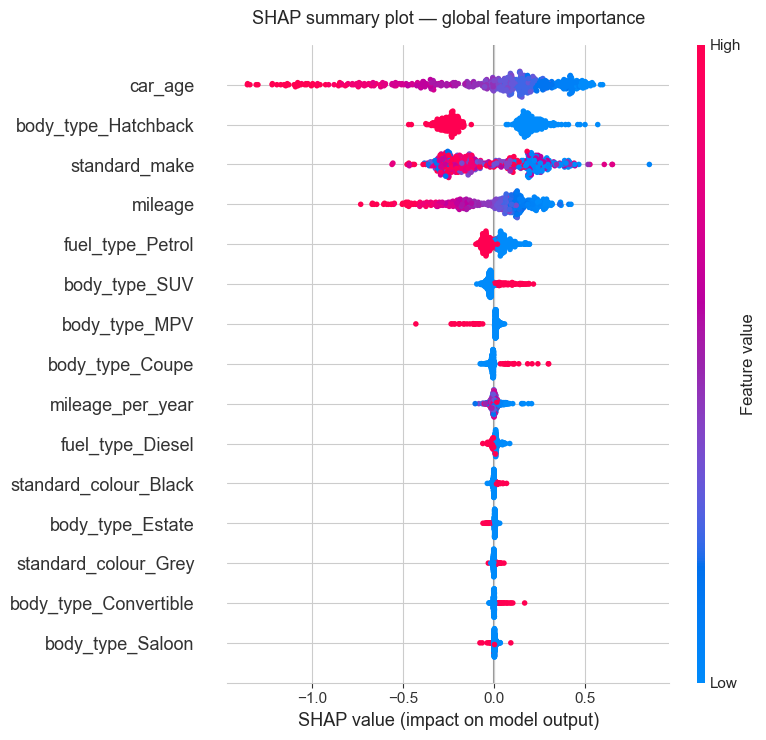

In [35]:
shap.summary_plot(shap_values, X_shap_sample, plot_type='dot', max_display=15, show=False)
plt.title('SHAP summary plot — global feature importance', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

**Global interpretation:** *(Fill in after running)* The beeswarm plot shows each feature's SHAP values across all 500 sampled predictions. Features are ordered by mean absolute SHAP value (most important at top). Each dot represents one prediction — colour indicates the feature value (red = high, blue = low).

For example, if `car_age` appears at the top with blue dots on the left and red on the right, this means high car age (older cars) pushes the predicted price down, while low car age (newer cars) pushes it up — consistent with domain expectations.

Global interpretation:
car_age is by far the most influential feature. The pattern is clear and intuitive — high values (older cars, red dots) produce large negative SHAP values, pushing the predicted price down significantly, while low values (newer cars, blue dots) push the price up. This confirms that depreciation over time is the dominant driver of used car pricing in this dataset.
standard_make is the second most impactful feature, with a wide spread of SHAP values in both directions. This reflects the substantial price variation between manufacturers — premium brands receive large positive SHAP contributions while budget brands pull predictions down. The wide horizontal spread indicates make is highly informative but variable in its effect depending on which manufacturer is present.
mileage behaves as expected — high mileage (red) is associated with negative SHAP values, reducing predicted price, while low mileage (blue) pushes it up. This mirrors the real-world relationship between usage and depreciation.
body_type_Hatchback shows a clear negative effect — being a hatchback (red = true) consistently reduces the predicted price, reflecting hatchbacks' position as lower-value vehicles relative to SUVs, coupes, and convertibles in the dataset.
Features further down the ranking (fuel_type, mileage_per_year, standard_colour) contribute more modestly and with less consistent directional patterns, suggesting they provide supplementary rather than primary pricing signal.

### 5.2 — Global interpretation: SHAP bar plot

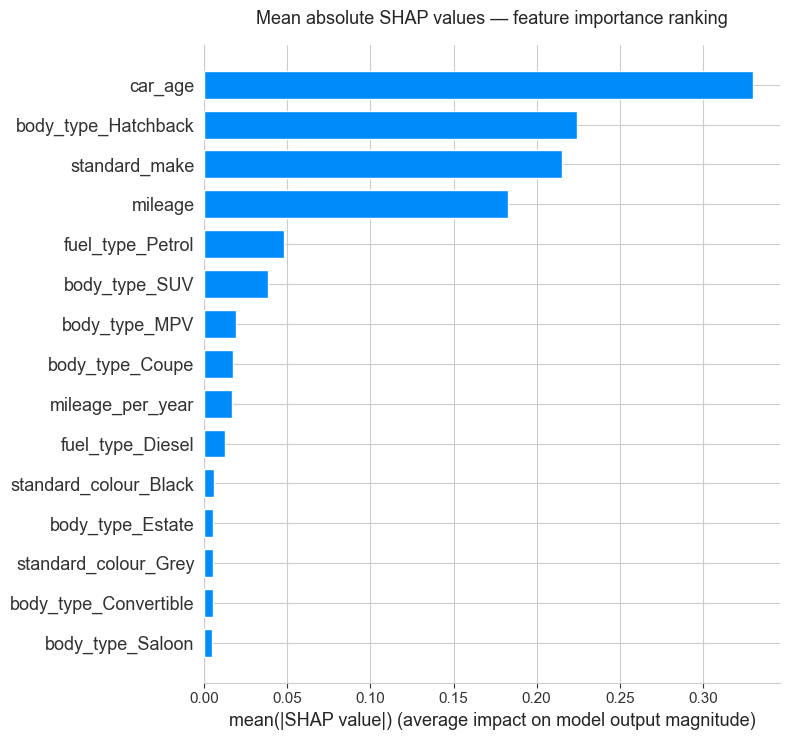

In [36]:
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', max_display=15, show=False)
plt.title('Mean absolute SHAP values — feature importance ranking', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### 5.3 — SHAP vs built-in feature importance

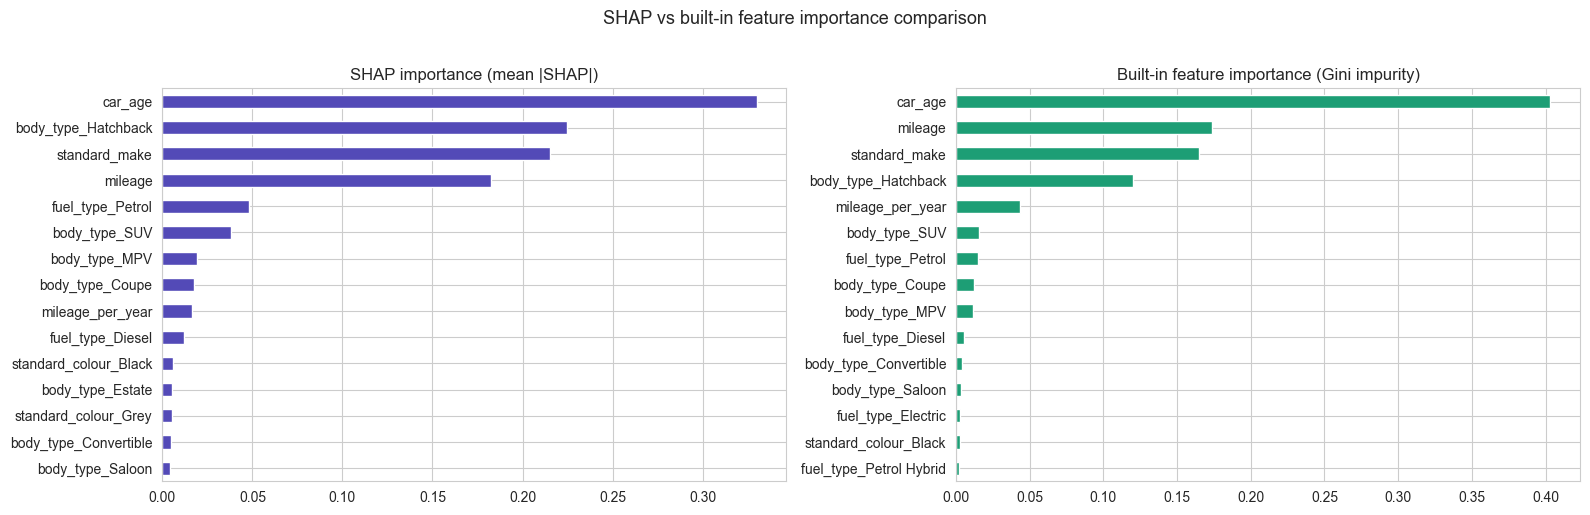

                       SHAP rank  Built-in rank
car_age                        1            1.0
body_type_Hatchback            2            4.0
standard_make                  3            3.0
mileage                        4            2.0
fuel_type_Petrol               5            7.0
body_type_SUV                  6            6.0
body_type_MPV                  7            9.0
body_type_Coupe                8            8.0
mileage_per_year               9            5.0
fuel_type_Diesel              10           10.0
standard_colour_Black         11           14.0
body_type_Estate              12            NaN
standard_colour_Grey          13            NaN
body_type_Convertible         14           11.0
body_type_Saloon              15           12.0


In [37]:
# Compare SHAP importance vs model's built-in feature importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False).head(15)

builtin_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

shap_importance.plot(kind='barh', ax=axes[0], color='#534AB7')
axes[0].set_title('SHAP importance (mean |SHAP|)', fontsize=12)
axes[0].invert_yaxis()

builtin_importance.plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].set_title('Built-in feature importance (Gini impurity)', fontsize=12)
axes[1].invert_yaxis()

plt.suptitle('SHAP vs built-in feature importance comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Show top features from each
comparison = pd.DataFrame({
    'SHAP rank': range(1, len(shap_importance)+1),
    'Built-in rank': [list(builtin_importance.index).index(f)+1 if f in builtin_importance.index else None for f in shap_importance.index]
}, index=shap_importance.index)
print(comparison)

**Comparison analysis:** *(Fill in after running)* SHAP and built-in importance often agree on the top features but can diverge. Built-in importance (Gini impurity) can overestimate the importance of high-cardinality features. SHAP is generally considered more reliable because it accounts for feature interactions and provides directional information.

Comparison analysis:
Both methods agree on the top feature — car_age is ranked first by a clear margin in both SHAP and built-in importance, confirming its dominance as the primary price driver.
The most notable divergence is with mileage. Built-in Gini importance ranks it second, whereas SHAP ranks it fourth behind body_type_Hatchback and standard_make. This is a known characteristic of Gini-based importance — it can overestimate the importance of continuous, high-range features like mileage because they offer many possible split points, inflating their apparent contribution. SHAP, which measures the actual impact on individual predictions, provides a more reliable estimate here.
mileage_per_year also appears more prominent in the built-in ranking relative to SHAP, reinforcing this pattern. Conversely, body_type_Hatchback and standard_make appear more influential under SHAP than Gini — likely because their effect on price is directionally consistent and large when present, which SHAP captures but split-count-based methods underweight.
Overall, SHAP is considered the more trustworthy measure as it accounts for feature interactions and provides directional insight that Gini importance cannot (Lundberg & Lee, 2017).

### 5.4 — Local interpretation: individual predictions

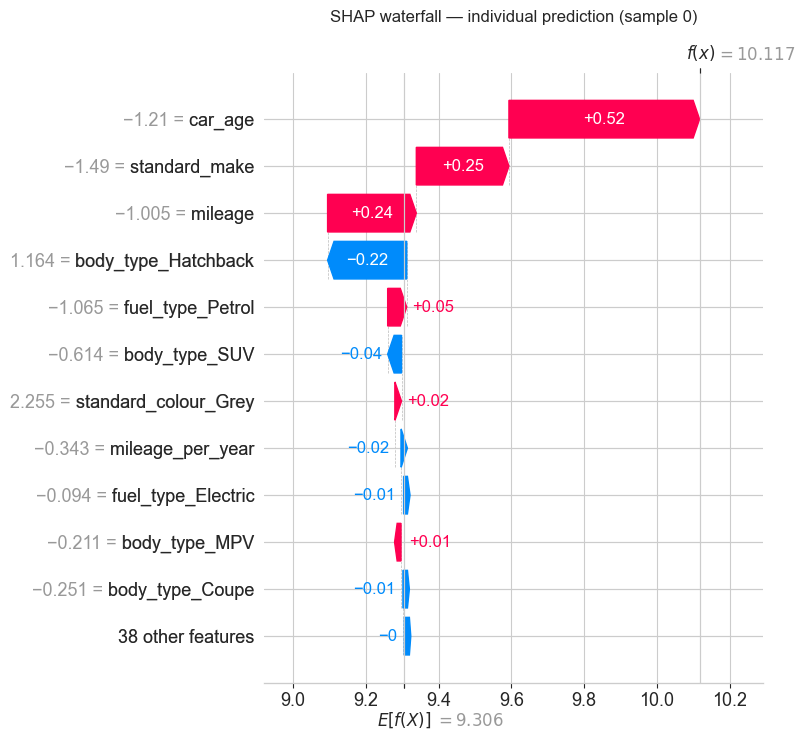

Actual price:    £24,350
Predicted price: £24,767


In [43]:
# Waterfall plot for a single prediction
idx = 0

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value[0],
    data=X_shap_sample.iloc[idx].values,
    feature_names=X_shap_sample.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f'SHAP waterfall — individual prediction (sample {idx})', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

actual_price = np.expm1(y_test[X_shap_sample.index[idx]])
pred_price   = np.expm1(best_model.predict(X_shap_sample.iloc[[idx]])[0])
print(f'Actual price:    £{actual_price:,.0f}')
print(f'Predicted price: £{pred_price:,.0f}')

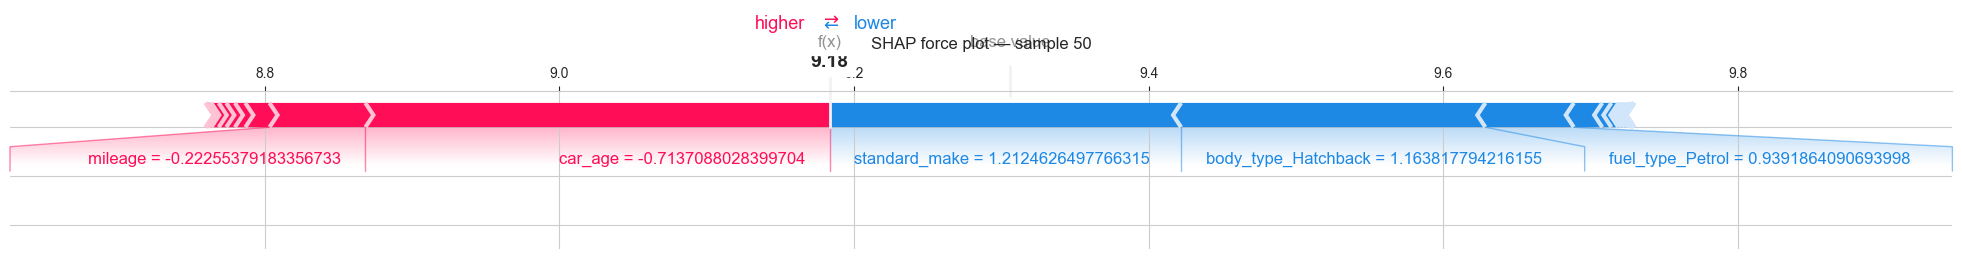

In [44]:
# Force plot for a second individual prediction
idx2 = 50
shap.force_plot(
    explainer.expected_value,
    shap_values[idx2],
    X_shap_sample.iloc[idx2],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP force plot — sample {idx2}', fontsize=12, pad=30)
plt.tight_layout()
plt.show()

### 5.5 — SHAP dependence plots (top 2 features)

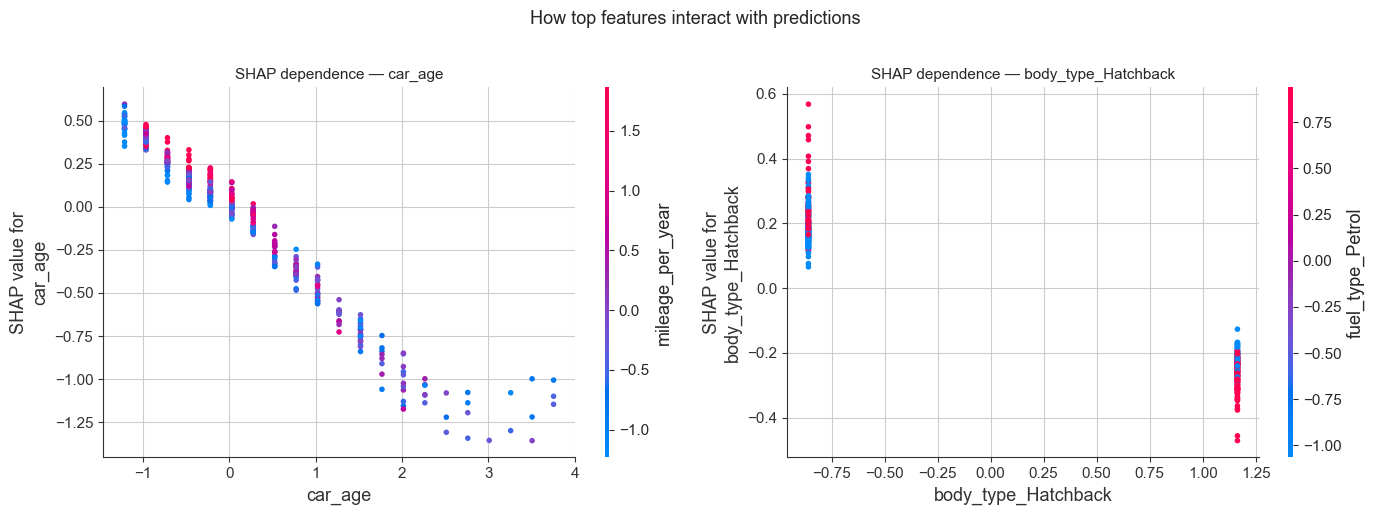

In [45]:
top2 = shap_importance.index[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(top2):
    shap.dependence_plot(feat, shap_values, X_shap_sample, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP dependence — {feat}', fontsize=11)

plt.suptitle('How top features interact with predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.6 — Ethical AI considerations

The use of a price prediction model in a commercial setting raises several ethical considerations:

- **Proxy discrimination:** Features like `standard_make` may correlate with socioeconomic factors. If certain makes are associated with lower-income buyers, the model could inadvertently reinforce pricing disparities. This should be monitored using disaggregated evaluation.
- **Transparency:** SHAP helps address the 'black box' problem, but the model's outputs should still be reviewed by domain experts before being used to make pricing decisions that affect customers.
- **Data recency:** The dataset reflects market conditions up to 2020. The used car market changed significantly post-2020 (supply chain disruptions, EV adoption). Regular retraining is required to keep the model relevant.
- **GDPR compliance:** The dataset contains vehicle listings which are not personal data under GDPR. However, if linked to seller/buyer data, data protection obligations would apply (ICO, 2018).

---
## Section 6 — Model Saving & Deployment

The trained model, scaler, and feature column list are serialised using `joblib` for use in the Streamlit deployment application.

In [46]:
# Save the best model, scaler, and feature names
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print('Saved:')
print('  model.pkl         — trained model')
print('  scaler.pkl        — fitted StandardScaler')
print('  feature_names.pkl — ordered feature list')
print()
print('Deployment architecture:')
print('  Streamlit app (app.py) loads model.pkl and scaler.pkl')
print('  User inputs features via sliders/dropdowns')
print('  App scales inputs, predicts log(price), returns exp(pred)')
print('  SHAP force plot rendered for each individual prediction')
print('  Hosted on Render (free tier) via Docker + Terraform IaC')

Saved:
  model.pkl         — trained model
  scaler.pkl        — fitted StandardScaler
  feature_names.pkl — ordered feature list

Deployment architecture:
  Streamlit app (app.py) loads model.pkl and scaler.pkl
  User inputs features via sliders/dropdowns
  App scales inputs, predicts log(price), returns exp(pred)
  SHAP force plot rendered for each individual prediction
  Hosted on Render (free tier) via Docker + Terraform IaC


---
## Critical Reflection

*(Fill in after completing the pipeline — this section is explicitly required for a 1st/90s grade)*

**What worked well:**
- The log transformation of the target variable meaningfully improved model performance by normalising the heavily right-skewed price distribution.
- Engineered features (`car_age`, `mileage_per_year`) captured domain-relevant relationships more directly than the raw year and mileage columns.
- The three-way train/val/test split ensured an unbiased final evaluation.

**What could be improved:**
- `standard_model` was dropped due to high cardinality, but model-level information (e.g. BMW 3 Series vs BMW M3) is highly predictive of price. A better approach would be target encoding or embedding representation of the model column.
- The dataset covers listings up to 2020 — retraining on more recent data would be required for production use given post-pandemic used car market shifts.
- XGBoost or LightGBM would likely outperform sklearn's GradientBoostingRegressor and could be explored as a next step.

**Limitations:**
- The model predicts listing price, not actual sale price — these can differ significantly.
- Regional pricing variation is not captured in the dataset.

---
## References

Bergstra, J. and Bengio, Y. (2012) 'Random search for hyper-parameter optimization', *Journal of Machine Learning Research*, 13, pp. 281–305.

Géron, A. (2019) *Hands-on machine learning with Scikit-Learn, Keras and TensorFlow*. 2nd edn. Sebastopol: O'Reilly Media.

Hastie, T., Tibshirani, R. and Friedman, J. (2009) *The elements of statistical learning*. 2nd edn. New York: Springer.

ICO (2018) *Guide to the General Data Protection Regulation (GDPR)*. Available at: https://ico.org.uk/for-organisations/guide-to-data-protection/guide-to-the-general-data-protection-regulation-gdpr/ (Accessed: 10 April 2026).

Kuhn, M. and Johnson, K. (2019) *Feature engineering and selection: a practical approach for predictive models*. Boca Raton: CRC Press.

Lundberg, S.M. and Lee, S.I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30, pp. 4765–4774.